In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import ast

url = "https://raw.githubusercontent.com/nkmwicz/worldcup2018data/refs/heads/main/cleaned_events_world_cup2018.csv"
df = pd.read_csv(url)

df["tags"] = df["tags"].apply(ast.literal_eval)

df.head(1)

,eventId,subEventName,tags,playerId,matchId,eventName,teamId,matchPeriod,eventSec,subEventId,id,x1,y1,x2,y2
0,8,Simple pass,[Accurate],Mohammad Ibrahim Al Sahlawi,"Russia - Saudi Arabia, 5 - 0",Pass,Saudi Arabia,1H,1.656214,Simple pass,258612104,50,50,35.0,53.0


pearson r has to be continuous, numeric (2 variables), and only linear!

In [3]:
x_max = 120
y_max = 75

df["x1"] = (df["x1"] /100) * x_max
df["x2"] = (df["x2"] /100) * x_max
df["y1"] = (df["y1"] /100) * y_max
df["y2"] = (df["y2"] /100) * y_max


In [4]:
df.head(1)

,eventId,subEventName,tags,playerId,matchId,eventName,teamId,matchPeriod,eventSec,subEventId,id,x1,y1,x2,y2
0,8,Simple pass,[Accurate],Mohammad Ibrahim Al Sahlawi,"Russia - Saudi Arabia, 5 - 0",Pass,Saudi Arabia,1H,1.656214,Simple pass,258612104,60.0,37.5,42.0,39.75


In [5]:
df["shot"] = (df["eventName"] == "Shot").astype(int)
df.loc[df["shot"] == 1, ["x2", "y2"]]

,x2,y2
117,120.0,75.0
154,0.0,0.0
197,0.0,0.0
232,0.0,0.0
372,120.0,75.0
...,...,...
101371,120.0,75.0
101457,120.0,75.0
101493,120.0,75.0
101620,0.0,0.0


In [7]:
box_h = 44
box_w = 18

box_ymin = (y_max / 2) - (box_h / 2) 
box_ymax = (y_max / 2) + (box_h / 2)
box_xmax = x_max
box_xmin = x_max - box_w


df["golden_event"] = (
    (box_ymin < df["y1"]) &
    (df["y1"]< box_ymax) &
    (box_xmin < df["x1"]) &
    (df["x1"] < box_xmax)
    ).astype(int)
df["golden_event"].sum()

np.int64(3989)

In [9]:
# independent = golden events , dependent = shots ; group by match id and team id to get shots and golden events per team per match

g_df = df.groupby(["matchId", "teamId"]).agg(
    shots = ("shot", "sum"),
    golden_events = ("golden_event", "sum")
).reset_index()

g_df

,matchId,teamId,shots,golden_events
0,"Argentina - Croatia, 0 - 3",Argentina,10,34
1,"Argentina - Croatia, 0 - 3",Croatia,13,25
2,"Argentina - Iceland, 1 - 1",Argentina,22,56
3,"Argentina - Iceland, 1 - 1",Iceland,8,25
4,"Australia - Peru, 0 - 2",Australia,11,48
...,...,...,...,...
123,"Uruguay - Portugal, 2 - 1",Uruguay,6,16
124,"Uruguay - Russia, 3 - 0",Russia,3,15
125,"Uruguay - Russia, 3 - 0",Uruguay,12,24
126,"Uruguay - Saudi Arabia, 1 - 0",Saudi Arabia,7,16


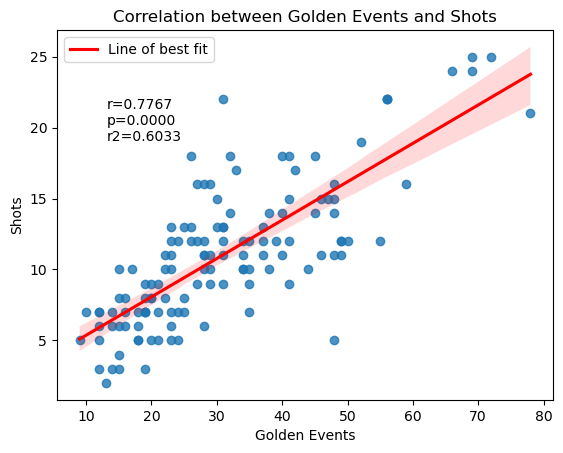

In [11]:
r, p = stats.pearsonr(g_df["golden_events"], g_df["shots"])
r2 = r**2
text = f""" 
r={r:.4f}
p={p:.4f}
r2={r2:.4f}"""
reg = sns.regplot(data = g_df, 
                  x = "golden_events", 
                  y = "shots",
                  line_kws={"color": "red", "label": "Line of best fit"})
reg.text(x=0.1, y=0.7, s=text, transform=reg.transAxes)
reg.set(title = "Correlation between Golden Events and Shots", 
        xlabel = "Golden Events", 
        ylabel = "Shots")
plt.legend()

